<a href="https://colab.research.google.com/github/AmandaElisa/gems-finder-tic-ia2/blob/main/notebook/gems_finder_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 💎 Gems Finder — Análise Exploratória e Metodologia

**Residência em IA · UnB — Turma 2 · Grupo 9 · Nano-Challenge: Spotify Data**

Este notebook segue a metodologia registrada em
[`docs/specs/2026-09-01-recommender-methodology/spec.md`](../docs/specs/2026-09-01-recommender-methodology/spec.md).
Cada seção abaixo corresponde a uma etapa dessa spec, e as seções marcadas
**A FAZER** são o trabalho que ainda não foi implementado.

**Abordagem:** *Content-Based Filtering* sobre atributos de áudio. Essa escolha
é imposta pelos dados, não é preferência: o dataset não traz metadado nenhum
de ouvinte (idade, localização, histórico), então não existe interação
usuário-item para filtragem colaborativa aprender.

## 1. Perguntas norteadoras

**Dados (qualidade e engenharia)**
- Existem nulos ou campos corrompidos que exijam tratamento ou imputação?
- Existem faixas duplicadas (`track_id` repetido, ou mesmo nome e artista com
  IDs diferentes) capazes de distorcer as análises?
- Existem outliers que devam ser tratados como ruído?
- Que metadados de ouvinte estão disponíveis? *(resposta: nenhum — ver acima)*

**Viés de popularidade**
- O modelo prioriza excessivamente artistas consolidados?
- Quais atributos mais se correlacionam com a popularidade?
- Quais gêneros de baixa popularidade média têm características de áudio
  parecidas com os de alta popularidade?
- Qual o limiar estatístico de `popularity` que define uma faixa genuinamente
  "escondida"?

**Arquitetura de recomendação**
- Como combinar `valence`, `energy`, `acousticness` e `speechiness` para
  segmentar o catálogo em *moods*?
- Como construir um **Score de Potencial Oculto** que mapeie faixas
  subestimadas cujos atributos se aproximem dos grandes sucessos?
- Como estruturar o modelo para que, ao gostar de um sucesso, o usuário receba
  uma joia escondida com o mesmo DNA sonoro?

## 2. Carga dos dados

O dataset mora no próprio repositório (`data/raw/`, 20 MB), então o notebook
roda na máquina de qualquer pessoa do grupo, sem conta Google e sem montar o
Drive. O caminho é relativo ao repositório, e o fallback do Colab fica
disponível para quem preferir rodar por lá.

In [1]:
from pathlib import Path

import pandas as pd

# Procura o dataset a partir do notebook e da raiz do repo, nessa ordem.
CANDIDATOS = [
    Path("../data/raw/dataset_spotify_raw.csv"),
    Path("data/raw/dataset_spotify_raw.csv"),
]
CAMINHO = next((c for c in CANDIDATOS if c.exists()), None)

if CAMINHO is None:
    # Fallback para quem estiver no Colab: monta o Drive e usa a cópia de lá.
    from google.colab import drive
    drive.mount("/content/drive")
    CAMINHO = Path("/content/drive/MyDrive/dataset(in).csv")

df = pd.read_csv(CAMINHO)
print(f"Carregado de: {CAMINHO}")
print(f"{len(df):,} faixas · {len(df.columns)} colunas")
df.head()

Carregado de: ..\data\raw\dataset_spotify_raw.csv
114,000 faixas · 21 colunas


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [2]:
# A coluna "Unnamed: 0" é só o índice que veio salvo no CSV, não é informação.
if "Unnamed: 0" in df.columns:
    df = df.drop(columns="Unnamed: 0")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

## 3. Qualidade dos dados

Aqui respondemos as três primeiras perguntas norteadoras com número, não com
impressão.

In [3]:
df.shape

(114000, 20)

In [4]:
# Nulos por coluna — só as que têm algum.
nulos = df.isnull().sum()
nulos[nulos > 0]

artists       1
album_name    1
track_name    1
dtype: int64

In [5]:
# Duplicatas nas duas formas que a spec distingue.
dup_id = df["track_id"].duplicated().sum()
dup_nome = df.duplicated(subset=["track_name", "artists"]).sum()

print(f"track_id duplicados                       : {dup_id:,} ({dup_id/len(df):.1%})")
print(f"mesmo (track_name, artists), IDs distintos: {dup_nome:,} ({dup_nome/len(df):.1%})")
print(f"gêneros distintos                         : {df['track_genre'].nunique()}")

track_id duplicados                       : 24,259 (21.3%)
mesmo (track_name, artists), IDs distintos: 32,658 (28.6%)
gêneros distintos                         : 114


**Atenção — a duplicação é estrutural, não sujeira.** Este dataset repete a
faixa uma vez por gênero a que ela pertence: é assim que a associação
faixa↔gênero é expressa. Para centroide por gênero isso está correto. Para
qualquer varredura global do catálogo é contagem dupla.

Consequência prática: o cruzamento das faixas mais ouvidas do usuário com o
catálogo **não pode** ser um `merge` direto por `track_id` — com ~21% de
duplicatas, o merge multiplica linhas e distorce a média do perfil. Deduplicar
antes, e decidir explicitamente qual gênero a faixa deduplicada mantém.

In [6]:
# Quantas faixas sobram sem a duplicação por gênero.
unicas = df.drop_duplicates(subset="track_id")
print(f"faixas únicas por track_id: {len(unicas):,} de {len(df):,}")

faixas únicas por track_id: 89,741 de 114,000


## 4. Análise descritiva

In [7]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [8]:
explicit_songs_per_genre = (df[df["explicit"] == True]
                            .groupby("track_genre").size()
                            .sort_values(ascending=False))
print(explicit_songs_per_genre)

track_genre
comedy         656
emo            465
sad            450
j-dance        391
hardcore       325
              ... 
rock-n-roll      2
disney           1
j-idol           1
opera            1
pop-film         1
Length: 106, dtype: int64


In [9]:
df["album_name"].value_counts()

album_name
Alternative Christmas 2022                              195
Feliz Cumpleaños con Perreo                             184
Metal                                                   143
Halloween con perreito                                  123
Halloween Party 2022                                    115
                                                       ... 
Hold On (Remix)                                           1
The Boy Who Never                                         1
Build Your Kingdom Here (A Rend Collective Mix Tape)      1
More Like Jesus (Live)                                    1
Psalms                                                    1
Name: count, Length: 46579, dtype: int64

## 5. Popularidade: distribuição e limiar do "escondido"

O limiar define o produto. Duas definições estão em disputa na spec (§9): o
percentil 20 do relatório e o slider de 1–40 do app. Os números abaixo mostram
o quanto elas diferem.

In [10]:
p = df["popularity"]
print(f"min={p.min()}  percentil 20={p.quantile(.20):.0f}  "
      f"mediana={p.median():.0f}  percentil 80={p.quantile(.80):.0f}  max={p.max()}")

for teto in (10, 20, 30, 40):
    fatia = (p <= teto).mean()
    print(f"popularity <= {teto:>2}: {(p <= teto).sum():>7,} faixas ({fatia:.1%} do catálogo)")

min=0  percentil 20=10  mediana=35  percentil 80=54  max=100
popularity <= 10:  23,462 faixas (20.6% do catálogo)
popularity <= 20:  34,177 faixas (30.0% do catálogo)
popularity <= 30:  51,756 faixas (45.4% do catálogo)
popularity <= 40:  67,326 faixas (59.1% do catálogo)


## 6. Correlação dos atributos com a popularidade

Responde "quais atributos são mais correlacionados com a popularidade?" e serve
de insumo para a seleção de features (§7), evitando multicolinearidade.

In [11]:
# Só as colunas numéricas entram na matriz de correlação.
numeric_df = df.select_dtypes(include=["number"])
df_corr = numeric_df.corr()
display(df_corr)

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007101,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073
duration_ms,-0.007101,1.000000,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225
danceability,0.035448,-0.073426,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218
energy,0.001056,0.058523,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126
key,-0.003853,0.008114,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065
loudness,0.050423,-0.003470,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992
mode,-0.013931,-0.035556,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092
speechiness,-0.044927,-0.062600,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011
acousticness,-0.025472,-0.103788,-0.171533,-0.733906,-0.040937,-0.589803,0.095553,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224,-0.176138
instrumentalness,-0.095139,0.124371,-0.185606,-0.181879,-0.006823,-0.433477,-0.049955,-0.089616,0.104027,1.000000,-0.079893,-0.324312,-0.050330,-0.082580


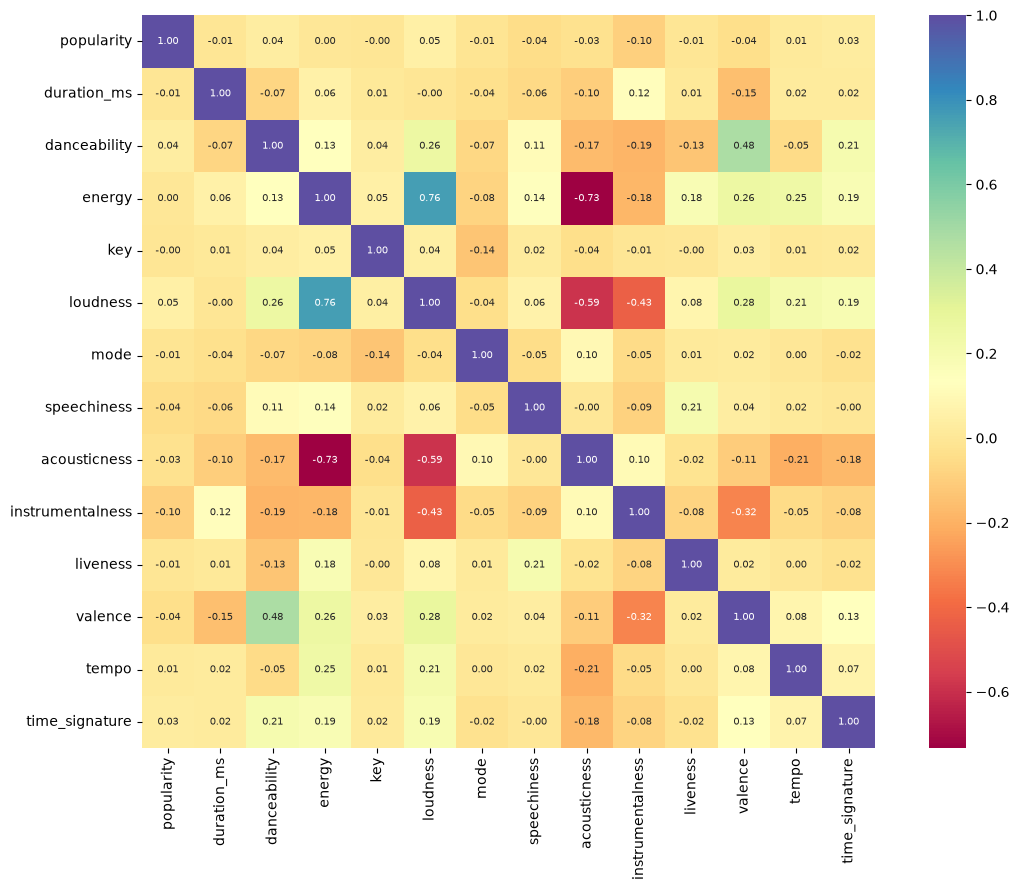

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_corr, fmt=".2f", square=True, linecolor="white",
            annot=True, annot_kws={"size": 7}, cmap="Spectral", ax=ax)
plt.tight_layout()

In [13]:
# A correlação de cada atributo com popularity, do mais forte ao mais fraco.
df_corr["popularity"].drop("popularity").sort_values(key=abs, ascending=False)

instrumentalness   -0.095139
loudness            0.050423
speechiness        -0.044927
valence            -0.040534
danceability        0.035448
time_signature      0.031073
acousticness       -0.025472
mode               -0.013931
tempo               0.013205
duration_ms        -0.007101
liveness           -0.005387
key                -0.003853
energy              0.001056
Name: popularity, dtype: float64

## 7. Seleção de features — **A FAZER**

A escolha das variáveis é empírica, não fixada por argumento. Técnicas
previstas na metodologia (spec §6.2):

| Técnica | O que decide |
|---|---|
| Variance Threshold, Mean Absolute Difference | Descartar atributos com variabilidade baixa demais para separar qualquer coisa |
| Pearson (§6 acima) | Relações lineares entre atributos contínuos, evitando multicolinearidade |
| Information Gain, Fisher's Score | Relevância preditiva de cada métrica frente aos agrupamentos de humor e popularidade |

O conjunto final de features é o que esses testes sustentarem — e o resultado
deles precisa ficar commitado aqui, não só citado.

## 8. Segmentação em moods (clusters) — **A FAZER**

Combinar `valence`, `energy`, `acousticness` e `speechiness` para segmentar o
catálogo nos quadrantes de humor. O protótipo aprovado usa quatro: **Foco,
Treino, Chill, Melancolia** (`src/dados.py::VIBES`), hoje definidos por vetores
alvo ajustados à mão. A pergunta aberta é se os clusters encontrados nos dados
confirmam esses quatro grupos ou sugerem outros.

## 9. Similaridade: k-NN + cosseno e grafo de atributos — **A FAZER**

Metodologia da spec §6.3: grafo de conteúdo sobre o dataset interno, com nós de
faixa (`track_id`), artista, gênero e faixas vizinhas por proximidade
estrutural; motor de recomendação com **k-NN + similaridade de cosseno**.

**Divergência a resolver antes de implementar:** o app hoje usa distância
ponderada absoluta com pesos fixos à mão (`src/recomendacao.py::match`), que
**não** é cosseno sobre vizinhança k-NN — as duas ranqueiam o mesmo catálogo de
forma diferente. A spec §9 deixa em aberto se o app adota o modelo do
relatório, e a decisão deve sair da avaliação (§11), não de preferência.

## 10. Filtro de viés de popularidade (`is_consolidated`) — **A FAZER**

O diferencial de negócio (spec §6.4): mapear o status do artista
(Consolidado × Independente) por agregação de métricas de catálogo e aplicar o
filtro estrito `is_consolidated == 'Independente'` antes de devolver o
resultado.

É **filtro, não penalização**: a faixa de artista consolidado não é
rebaixada no ranking, é excluída. É o mecanismo que atende o Lucas (persona 2).

**Regra ainda não definida:** o que exatamente torna um artista "consolidado" —
limiar sobre a popularidade média, piso de número de faixas, ou os dois.

## 11. Avaliação offline — Precisão @8 — **A FAZER**

Hoje `PRECISAO_8` em `src/dados.py` é **placeholder**, com `TODO` no código, e
a UI marca isso de forma visível — o que é a regra da constituição
(princípio 2): métrica placeholder não chega ao usuário sem marca.

Para substituir por número real precisamos de um protocolo de avaliação
escrito e versionado. Sem protocolo acordado, o placeholder continua.

Também é aqui que se mede se o filtro do §10 corrige de fato o viés que ele
promete corrigir: qual a fração de artistas independentes nos resultados
devolvidos.